In [1]:
import pandas as pd

df = pd.read_csv("../data/filteredvehpub.csv")   # adjust path as needed
df.head()
df.shape

(256115, 13)

In [2]:
df.columns

Index(['HOUSEID', 'HHFAMINC', 'HHSIZE', 'LIF_CYC', 'CENSUS_R', 'URBAN',
       'VEHID', 'DRVRCNT', 'MAKE', 'HH_RACE', 'WRKCOUNT', 'HOMEOWN',
       'URBANSIZE'],
      dtype='object')

In [3]:
import numpy as np
invalid_values = [-9, -8, -7, -88, 99, "99", "XX", "xx", "XX ", "-88", "-9", "-8", "-7"]
df = df.replace(invalid_values, np.nan)
df = df.dropna()

In [4]:
#df["VEHTYPE"] = df["VEHTYPE"].replace([5, 6], np.nan)
#df = df.dropna()

In [5]:
counts = df["MAKE"].value_counts()
counts.describe()

count       53.000000
mean      4619.924528
std       8184.317383
min         59.000000
25%        286.000000
50%       1584.000000
75%       4649.000000
max      34870.000000
Name: count, dtype: float64

In [6]:
df["MAKE"] = df["MAKE"].astype(str)   # convert everything to string first
df["MAKE"] = df["MAKE"].str.strip()   # remove whitespace
df["MAKE"] = df["MAKE"].astype(int)   # convert to integer

counts = df["MAKE"].value_counts()
rare_makes = counts[counts < 1743].index

df["MAKE"] = df["MAKE"].where(~df["MAKE"].isin(rare_makes), 98)
df["MAKE"].value_counts()

MAKE
12    34870
49    33679
20    31287
37    23895
98    16147
7     12576
35    11706
2      7309
48     6945
23     6915
55     6773
59     4980
18     4867
6      4713
63     4649
30     4622
34     4545
41     4340
42     3651
72     3094
19     2667
22     2665
54     2540
51     1832
14     1800
13     1789
Name: count, dtype: int64

In [7]:
#df.to_csv("processed_data.csv", index=False)

In [8]:
df.columns.tolist()

['HOUSEID',
 'HHFAMINC',
 'HHSIZE',
 'LIF_CYC',
 'CENSUS_R',
 'URBAN',
 'VEHID',
 'DRVRCNT',
 'MAKE',
 'HH_RACE',
 'WRKCOUNT',
 'HOMEOWN',
 'URBANSIZE']

In [9]:
feature_cols = [
    "HHSIZE",
    "HHFAMINC",
    "LIF_CYC",
    "CENSUS_R",
    "HH_RACE",
    "HOMEOWN",
    "WRKCOUNT",
    "URBAN",
    "URBANSIZE",
    "DRVRCNT"
]
target_col = "MAKE"
X = df[feature_cols]
y = df[target_col]

In [10]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler


numeric_features = ["HHSIZE", "HHFAMINC", "WRKCOUNT", "DRVRCNT"]
categorical_features = ["LIF_CYC", "CENSUS_R", "HH_RACE", "HOMEOWN", "URBAN", "URBANSIZE"]

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [11]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,           # use all CPU cores
    min_samples_split=4,
    min_samples_leaf=2
)

pipe = Pipeline([
    ("preprocess", preprocess),   # your ColumnTransformer from Step 7
    ("rf", rf)
])

pipe

,steps,"[('preprocess', ...), ('rf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [12]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
from tqdm import tqdm
import numpy as np

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = []

for train_idx, test_idx in tqdm(cv.split(X, y), total=5):
    X_train_cv, X_test_cv = X.iloc[train_idx], X.iloc[test_idx]
    y_train_cv, y_test_cv = y.iloc[train_idx], y.iloc[test_idx]

    # Fit pipeline
    pipe.fit(X_train_cv, y_train_cv)

    # Evaluate accuracy
    y_pred_cv = pipe.predict(X_test_cv)
    scores.append(accuracy_score(y_test_cv, y_pred_cv))

print("Cross-validated Accuracy:", np.mean(scores), "+/-", np.std(scores))

100%|█████████████████████████████████████████████| 5/5 [04:24<00:00, 52.96s/it]

Cross-validated Accuracy: 0.17121900343471988 +/- 0.00032568631337014054


In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, stratify=y, random_state=42 )

In [ ]:
pipe.fit(X_train, y_train)

In [15]:
from sklearn.metrics import accuracy_score

y_pred = pipe.predict(X_test)

test_acc = accuracy_score(y_test, y_pred)
print("Test Top-1 Accuracy:", test_acc)

Test Top-1 Accuracy: 0.1732418524871355


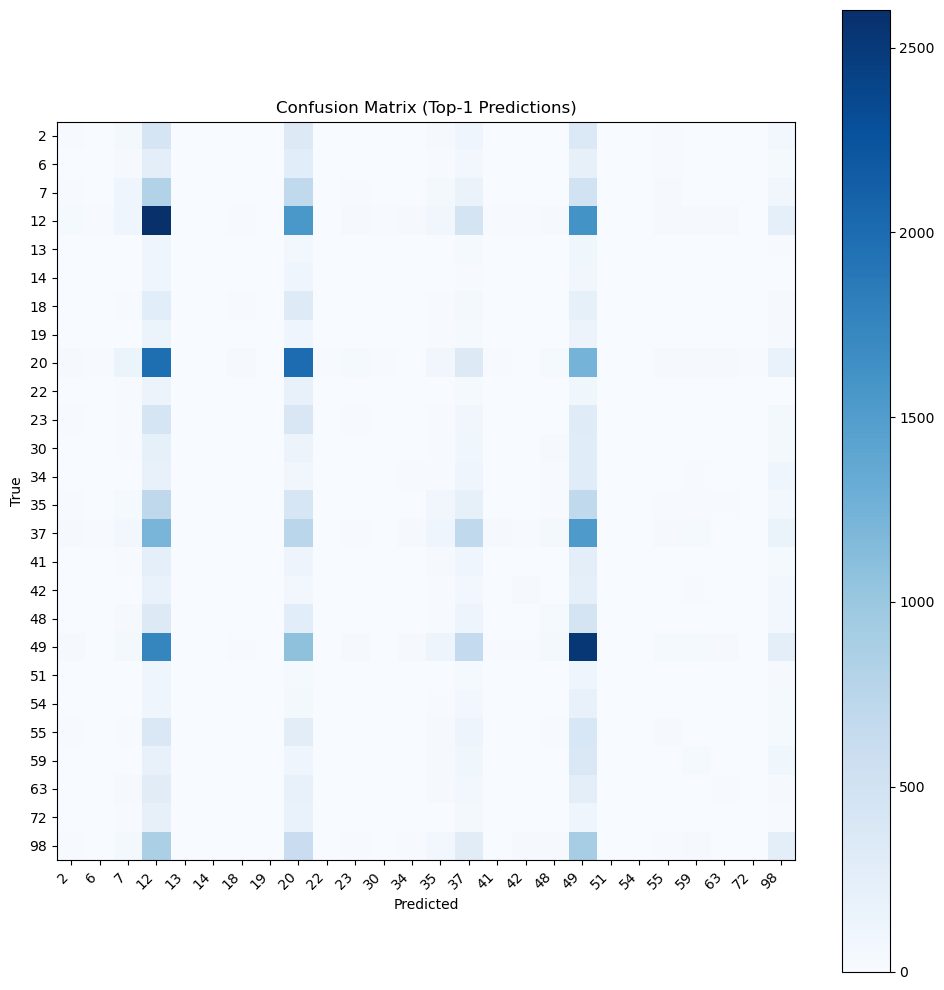

In [16]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(y_test, y_pred)

labels = sorted(y.unique())

fig, ax = plt.subplots(figsize=(10, 10))
im = ax.imshow(cm, cmap="Blues")
plt.colorbar(im)

ax.set_xticks(np.arange(len(labels)))
ax.set_yticks(np.arange(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_yticklabels(labels)

ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion Matrix (Top-1 Predictions)")

plt.tight_layout()
plt.show()